(integration_guide)=

# Integrating datasets by merging

Dataset integration starts by placing compatible assays in one datastore.
`DataStoreMerge` aligns their feature order, carries selected metadata, and records the source of each cell.
It does not alter expression values or correct the joint representation.
This guide builds that uncorrected baseline first.

## 1. Load compatible source stores

The control and interferon beta stimulated Kang PBMC stores use the same RNA feature space.
These prepared stores contain cells with author-provided cell-type labels.
Their `I` columns mark the cells that passed quality control.

In [1]:
# Import tools for creating and inspecting a merged count store.
from pathlib import Path
from tempfile import TemporaryDirectory

import pandas as pd

import cytearc

# Keep routine progress messages out of the teaching output.
cytearc.configure_output(level="ERROR", progress=False)

# Connect to the repository of prepared documentation datasets.
repository = cytearc.cytebase.connect("cytearc_docs")

# Download the control PBMC store.
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq", destination="cytearc_datasets", zarr=True
)

Started: 2026-10-08T11:03:05.780962Z | Wall time: 6.808 s

Download the stimulated sample from the same repository.

In [2]:
# Download the interferon-stimulated PBMC store.
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq", destination="cytearc_datasets", zarr=True
)

Started: 2026-10-08T11:03:12.591300Z | Wall time: 5.189 s

Open both source stores before checking their axes.

In [3]:
# Open the control sample.
ds_ctrl = cytearc.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)

# Open the stimulated sample.
ds_stim = cytearc.DataStore(f"{stim_path}/data.zarr", nthreads=4)

Started: 2026-10-08T11:03:17.784165Z | Wall time: 3.308 s

Confirm assay type, cell counts, and feature counts before merging. `DataStoreMerge` validates the
feature axes and requires every source to declare the same assay type, which the merged assay
keeps; matching gene symbols alone do not establish compatible genome builds or quantification
conventions.

In [4]:
# Compare assay types and cell and feature counts before merging.
pd.DataFrame(
    [
        {
            "source": label,
            "assay": type(store.RNA).__name__,
            "cells": store.cells.N,
            "active cells": int(store.cells.fetch_all("I").sum()),
            "features": store.RNA.feats.N,
        }
        for label, store in (("ctrl", ds_ctrl), ("stim", ds_stim))
    ]
)

,source,assay,cells,active cells,features
0,ctrl,RNAassay,8487,8486,35635
1,stim,RNAassay,10111,10111,35635


Started: 2026-10-08T11:03:21.095141Z | Wall time: 0.028 s

## 2. Merge counts and metadata

`names` supplies the source labels, `source_column` names their metadata column, and `prepend_text`
keeps imported metadata names distinct from columns authored in the merged store.
`reset_cell_filter=False` preserves the source quality-control selections.
A merge never replaces a store that a `DataStore` has opened, even with `overwrite=True`, so this
example writes into a new temporary folder each time it runs.

In [5]:
# Keep the merged example in a temporary folder.
merge_directory = TemporaryDirectory()

# Choose a new path for the merged counts.
merged_path = Path(merge_directory.name) / "kang_dataset_merging.zarr"

# Write the prepared counts and metadata to the new store.
cytearc.DataStoreMerge(
    datasets=[ds_ctrl, ds_stim],
    zarr_path=str(merged_path),
    names=["ctrl", "stim"],
    assays=["RNA"],
    prepend_text="orig",
    reset_cell_filter=False,
    source_column="sample_id",
).dump()

# Open the completed merge to inspect its cells and features.
merged = cytearc.DataStore(str(merged_path), nthreads=4)

# Check the merged cell and feature dimensions.
merged

DataStore has 18597 (18598) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_I', 'RNA_nCounts', 
            'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo', 'orig_RNA_UMAP1', 'orig_RNA_UMAP2', 
            'orig_RNA_clusters', 'orig_RNA_leiden_cluster', 'orig_cluster_labels', 'sample_id'
   RNA assay has 35635 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells'

Started: 2026-10-08T11:03:21.126005Z | Wall time: 27.271 s

`sample_id` records the source label.
Columns imported from the sources keep the `orig_` prefix so their origin remains explicit.
`RNA_I` marks the cells that the merged RNA assay measured; every cell here comes from an RNA
source, so it is True for all of them. When a source lacks an assay, or measured only some of its
cells with it, the merged `<assay>_I` column keeps that per-cell membership. Operations that read
that assay's values then refuse the cells it did not measure, whose counts are zero-filled, and
`merged.select_measured_cells("<assay>", cell_selection=...)` keeps the measured ones; here it
returns the selection unchanged, because RNA measured every cell.

The merged active population contains labelled cells from both sources.

In [6]:
# Read source labels and imported cell types for active cells.
merged_labels = merged.cells.to_pandas_dataframe(
    ["sample_id", "orig_cluster_labels"], key="I"
)

# Count active cells and distinct imported cell types from each source.
merged_labels.groupby("sample_id")["orig_cluster_labels"].agg(
    cells="count", cell_types="nunique"
)

,cells,cell_types
sample_id,,
ctrl,8486,13
stim,10111,13


Started: 2026-10-08T11:03:48.399709Z | Wall time: 0.049 s

## 3. Inspect a prepared joint analysis

The merge is complete. To see what these datasets look like together, open the catalog's prepared
merged store. It uses the same merge recipe and already contains PCA, clustering, and UMAP.
This is a separate store from `merged`, so the following plots do not run an analysis on the store
you just created. The saved example run is named `docs_default`.

In [7]:
# Download the separate, pre-analyzed joint example.
prepared_path = repository.download_dataset(
    name="kang_29K_ctrl-ifnb_pbmc_rnaseq", destination="cytearc_datasets", zarr=True
)

# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{prepared_path}/data.zarr", nthreads=4)

# Open the prepared baseline for the comparisons below.
baseline = ds.pipeline.open(label="docs_default")

# List the results available in the separate prepared analysis.
sorted(baseline)

['analysis_cell_selection',
 'ann_index',
 'cluster_selection',
 'clusters',
 'connectivity_map',
 'embedding_initialization',
 'feature_universe',
 'highly_variable_features',
 'input_cell_selection',
 'leiden_1.0',
 'neighbors',
 'normalized',
 'pca',
 'umap']

Started: 2026-10-08T11:03:48.450936Z | Wall time: 18.017 s

The durable run maps each output name to its exact {term}`artifact`.
Requested metadata and results remain in its frozen view.

One plotting call compares source identity, imported cell types, and the exact clustering artifact
on the same layout.

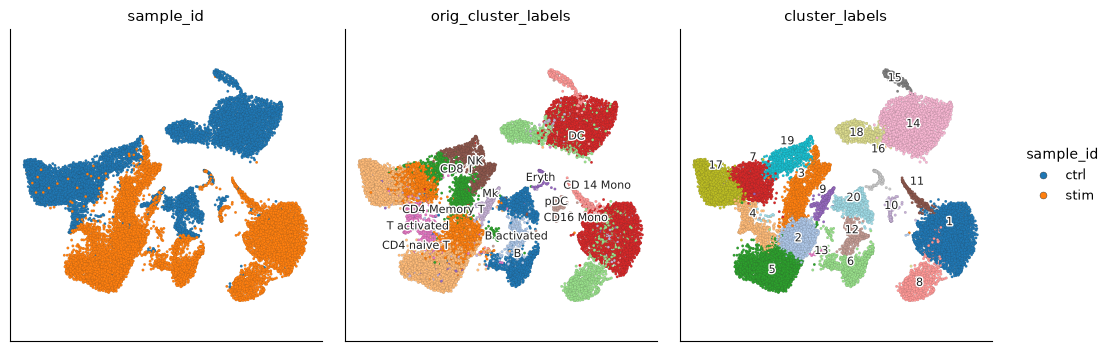

Started: 2026-10-08T11:04:06.469884Z | Wall time: 4.121 s

In [8]:
# Compare source labels, imported cell types, and computed clusters.
ds.plots.embedding(
    layout=baseline["umap"],
    color_by=["sample_id", "orig_cluster_labels", baseline["clusters"]],
    n_columns=3,
)

A table of proportions shows whether each Leiden cluster contains cells from both sources.

In [9]:
# Compare source proportions within each computed cluster.
pd.crosstab(
    baseline.cells.fetch("clusters"),
    baseline.cells.fetch("sample_id"),
    rownames=["cluster"],
    colnames=["source"],
    normalize="index",
).round(3)

source,ctrl,stim
cluster,,
1,0.004,0.996
2,0.006,0.994
3,0.008,0.992
4,0.443,0.557
5,0.002,0.998
6,0.002,0.998
7,0.974,0.026
8,0.010,0.990
9,0.429,0.571


Started: 2026-10-08T11:04:10.593808Z | Wall time: 0.155 s

The stimulated sample received interferon beta, and PBMC cell types do not all respond identically to that treatment.
Source-associated structure can therefore include biological response as well as technical variation.

The next page, [](batch_correction.ipynb), uses a different dataset with measured sequencing batches
to compare an uncorrected analysis with Harmony. It also introduces metrics for batch mixing.
Keep uncorrected counts for condition-level differential expression.